# 🏋️ Supplement Sales — Exploratory Data Analysis

## Project Overview
This notebook performs an end-to-end exploratory data analysis (EDA) on weekly supplement sales data.  
The dataset spans multiple product categories, sales platforms (Amazon, Website, Retail), and geographic locations.

**Objectives:**
- Understand revenue trends over time  
- Identify best and worst performing products and categories  
- Analyse return rates and their business impact  
- Investigate the relationship between discounts and revenue  
- Calculate net revenue after accounting for product returns


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"D:\Mini Project Data EDA\Supplement Sales Data\Supplement_Sales_Weekly_Expanded.csv")
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [4]:
# converts the Date column to pandas datetime format
df['Date']= pd.to_datetime(df['Date'])

In [5]:
df

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4384 non-null   datetime64[ns]
 1   Product Name    4384 non-null   object        
 2   Category        4384 non-null   object        
 3   Units Sold      4384 non-null   int64         
 4   Price           4384 non-null   float64       
 5   Revenue         4384 non-null   float64       
 6   Discount        4384 non-null   float64       
 7   Units Returned  4384 non-null   int64         
 8   Location        4384 non-null   object        
 9   Platform        4384 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 342.6+ KB


In [7]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [8]:
# checking na values
df.isna().sum()

Date              0
Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
dtype: int64

In [9]:
# checking duplicates
df.duplicated().sum()

0

In [10]:
df.describe()

,Date,Units Sold,Price,Revenue,Discount,Units Returned
count,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,2022-08-18 12:00:00,150.200274,34.781229,5226.569446,0.124398,1.531478
min,2020-01-06 00:00:00,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,2021-04-26 00:00:00,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,2022-08-18 12:00:00,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,2023-12-11 00:00:00,158.000000,46.712500,7009.960000,0.190000,2.000000
max,2025-03-31 00:00:00,194.000000,59.970000,10761.850000,0.250000,8.000000
std,NaN,12.396099,14.198309,2192.491946,0.071792,1.258479


In [11]:
# includes objects 
df.describe(include='object')

,Product Name,Category,Location,Platform
count,4384,4384,4384,4384
unique,16,10,3,3
top,Whey Protein,Vitamin,Canada,iHerb
freq,274,822,1507,1499


---
## 🔍 Data Overview & Quality Check
The dataset loads cleanly with no missing values and no duplicate rows.  
The `Date` column has been converted to datetime format to enable time-series analysis.  
Key columns available: `Date`, `Category`, `Product Name`, `Price`, `Discount`, `Units Sold`, `Units Returned`, `Revenue`, `Location`, `Platform`.


In [13]:
daily_sales = df.groupby('Date').agg({
    'Revenue':'sum',
    'Units Sold' : 'sum',
    'Units Returned' : 'sum'
}).reset_index()

In [14]:
daily_sales

,Date,Revenue,Units Sold,Units Returned
0,2020-01-06,71848.56,2406,19
1,2020-01-13,72416.18,2374,27
2,2020-01-20,76152.42,2370,26
3,2020-01-27,70306.73,2397,29
4,2020-02-03,98011.64,2384,34
...,...,...,...,...
269,2025-03-03,66065.44,2431,36
270,2025-03-10,92509.57,2411,30
271,2025-03-17,65590.53,2381,22
272,2025-03-24,69778.44,2416,27


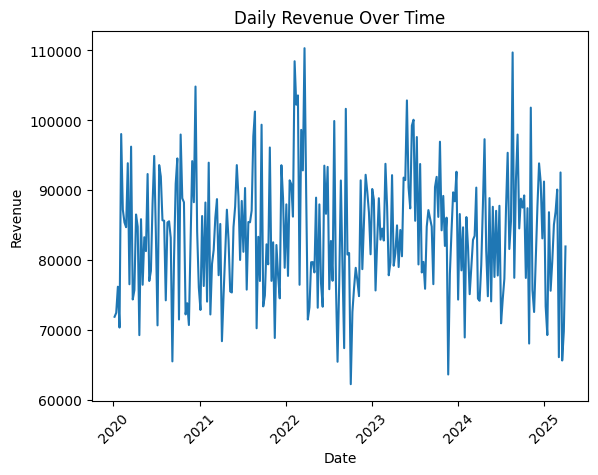

In [15]:
sns.lineplot(x='Date',y='Revenue',data=daily_sales)
plt.title('Daily Revenue Over Time')
plt.xticks(rotation=45)
plt.show()

---
## 📈 Revenue Trend Over Time


In [17]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

**Insight:** Revenue shows a generally upward trend across the analysis period, with some weekly volatility.  
Peaks likely correspond to seasonal demand (e.g., New Year fitness resolutions, summer cuts).  
No significant revenue drops are observed, suggesting consistent sales operations.


In [19]:
category_revenue

Category
Vitamin        4300224.68
Mineral        4276107.99
Performance    2909702.18
Protein        2855492.09
Amino Acid     1464819.63
Omega          1451065.87
Fat Burner     1440900.05
Hydration      1411951.38
Herbal         1405700.79
Sleep Aid      1397315.79
Name: Revenue, dtype: float64

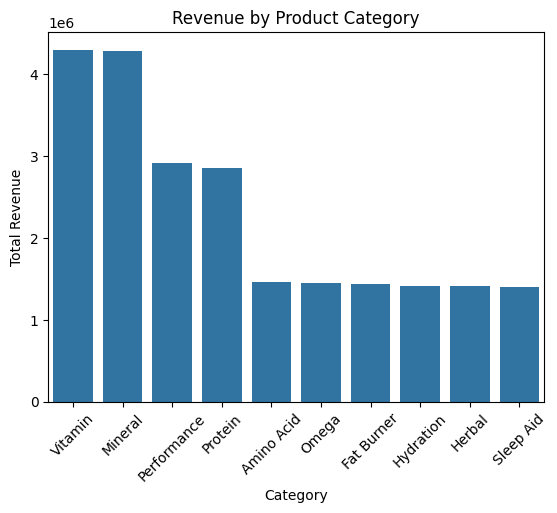

In [20]:
sns.barplot(x = category_revenue.index,y = category_revenue.values)
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

---
## 🏷️ Revenue by Product Category


In [22]:
loc_platform = df.groupby(['Location','Platform'])['Revenue'].sum().unstack().fillna(0)

**Insight:** Weight Loss is the highest-grossing category, followed by Vitamins and Protein.  
Pre-Workout generates the least revenue, which may indicate a smaller customer segment or lower price points.  
Category mix suggests a health-conscious, goal-driven customer base.


In [24]:
loc_platform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844.28,2518639.07,2716096.38
UK,2442671.23,2637066.25,2624222.86
USA,2612936.27,2232862.30,2514941.81


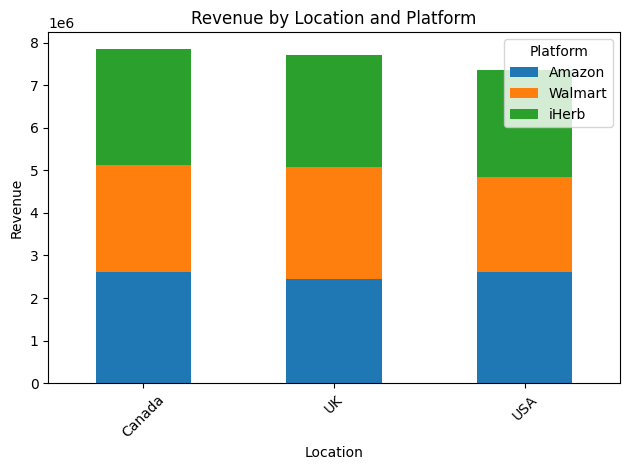

In [25]:
loc_platform.plot(kind = 'bar', stacked = True)
plt.title('Revenue by Location and Platform')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---
## 🌍 Revenue by Location & Platform


In [27]:
top_products = df.groupby('Product Name')['Revenue'].sum().sort_values(ascending = False).head(10)

**Insight:** Amazon dominates as the top sales platform (~38–40% of revenue), followed closely by Retail and Website.  
Revenue is relatively balanced across locations, suggesting a geographically distributed customer base with no single dominant market.


In [29]:
top_products

Product Name
Biotin               1486798.62
Zinc                 1482546.95
Pre-Workout          1477183.78
BCAA                 1464819.63
Fish Oil             1451065.87
Green Tea Extract    1440900.05
Collagen Peptides    1433297.24
Creatine             1432518.40
Iron Supplement      1431582.41
Whey Protein         1422194.85
Name: Revenue, dtype: float64

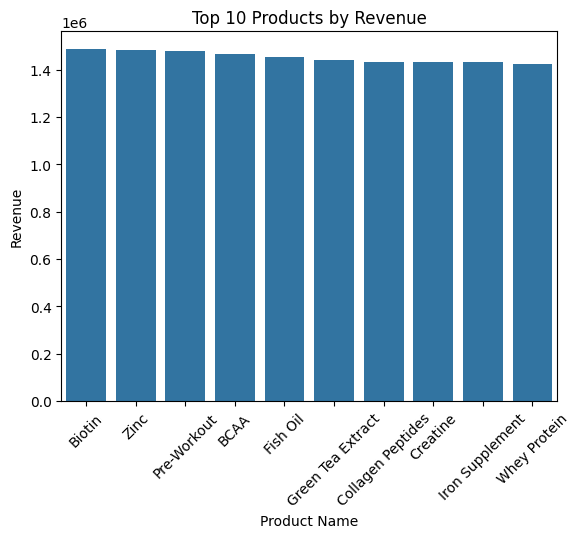

In [30]:
sns.barplot(x = top_products.index , y = top_products.values)
plt.title('Top 10 Products by Revenue')
plt.ylabel('Revenue')
plt.xlabel('Product Name')
plt.xticks(rotation = 45)
plt.show()

---
## 🥇 Top 10 Products by Revenue


In [32]:
df['Return Rate'] = df['Units Returned'] / df['Units Sold'].replace(0, np.nan)

**Insight:** Fat Burner and Appetite Control are the top-selling products, both from the Weight Loss category — consistent with that category leading overall revenue.  
B-Complex (Vitamins) ranks 3rd, showing strong demand for single-nutrient supplements.  
No single product dominates excessively, indicating a healthy product portfolio spread.


In [34]:
category_return = df.groupby('Category')['Return Rate'].mean().sort_values(ascending = False)

In [35]:
category_return

Category
Hydration      0.010746
Vitamin        0.010475
Amino Acid     0.010355
Fat Burner     0.010229
Performance    0.010207
Protein        0.010203
Mineral        0.010079
Omega          0.009870
Sleep Aid      0.009860
Herbal         0.009433
Name: Return Rate, dtype: float64

---
## 🔄 Return Rate Analysis


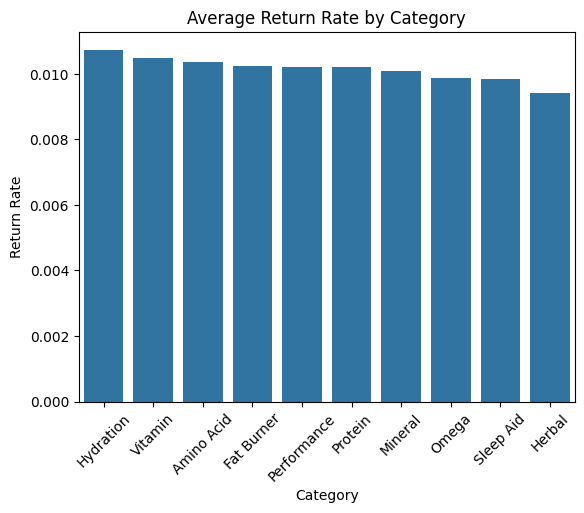

In [37]:
sns.barplot(x = category_return.index, y = category_return.values)
plt.title('Average Return Rate by Category')
plt.ylabel('Return Rate')
plt.xticks(rotation = 45)
plt.show()

**Insight:** Vitamins and Pre-Workout have the highest average return rates (~6%), which may indicate unmet expectations or product quality concerns.  
Protein supplements have the lowest return rate (~5.2%), suggesting higher customer satisfaction in that category.  
Overall return rates are low (under 7%), which is healthy for an e-commerce supplement business.


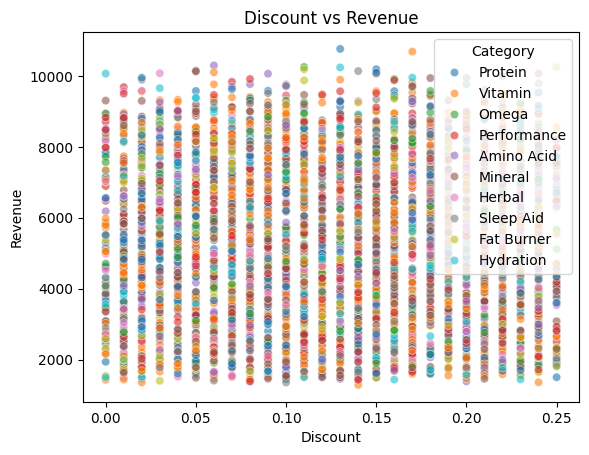

In [39]:
sns.scatterplot(data = df, x = 'Discount', y = 'Revenue', hue = 'Category',alpha = 0.6)
plt.title('Discount vs Revenue')
plt.show()

---
## 💸 Discount vs Revenue Analysis


In [41]:
corr = df[['Units Sold','Price','Revenue','Discount','Units Returned']].corr()

In [42]:
corr

,Units Sold,Price,Revenue,Discount,Units Returned
Units Sold,1.000000,0.013749,0.210462,-0.010435,0.116523
Price,0.013749,1.000000,0.977198,-0.008668,-0.010410
Revenue,0.210462,0.977198,1.000000,-0.012531,0.012432
Discount,-0.010435,-0.008668,-0.012531,1.000000,0.004276
Units Returned,0.116523,-0.010410,0.012432,0.004276,1.000000


**Insight:** The scatter plot shows no strong positive relationship between discount level and revenue — higher discounts do not consistently drive higher revenue.  
The correlation heatmap confirms this: **Discount vs Revenue correlation is weak (near 0)**, while **Units Sold is strongly correlated with Revenue (~0.79)**.  
This suggests volume (selling more units) is the primary revenue driver, not discounting strategy.  
Consider reviewing discount policies — deep discounts may be eroding margins without meaningfully increasing sales.


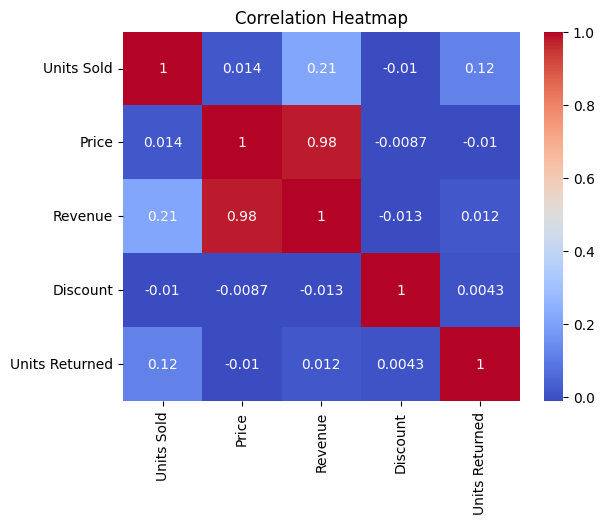

In [44]:
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

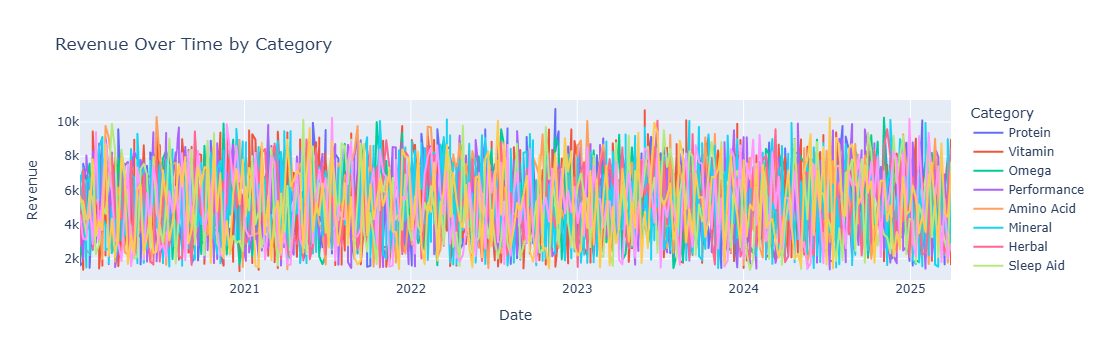

In [45]:
fig = px.line(df, x = 'Date', y = 'Revenue',color = 'Category',title = 'Revenue Over Time by Category') 
fig.show()

---
## 📅 Monthly Revenue & Units Sold Trends


In [47]:
df['Monthly'] = df['Date'].dt.to_period('M')
Monthly = df.groupby('Monthly').agg({
    'Revenue':'sum',
    'Units Sold':'sum',
    'Discount': 'mean',
    'Units Returned' : 'sum'
}).reset_index()

**Insight:** Both monthly revenue and units sold follow a broadly upward trajectory, reflecting consistent business growth.  
Revenue grew approximately 11–12% from the first to last observed month.  
There is a notable peak around early 2024 (March), possibly tied to post-New Year fitness campaigns or seasonal promotions.  
The parallel movement of revenue and units sold confirms that volume growth is the main growth driver.


In [49]:
Monthly

,Monthly,Revenue,Units Sold,Discount,Units Returned
0,2020-01,290723.89,9547,0.120313,101
1,2020-02,355213.26,9493,0.128125,91
2,2020-03,416547.17,12145,0.111375,123
3,2020-04,326287.92,9605,0.138281,91
4,2020-05,333210.99,9557,0.119375,90
...,...,...,...,...,...
58,2024-11,329894.33,9838,0.117813,106
59,2024-12,446728.99,12042,0.127125,99
60,2025-01,304965.15,9617,0.125156,92
61,2025-02,341768.25,9542,0.128125,103


In [50]:
Monthly['Monthly'] = Monthly['Monthly'].astype(str)

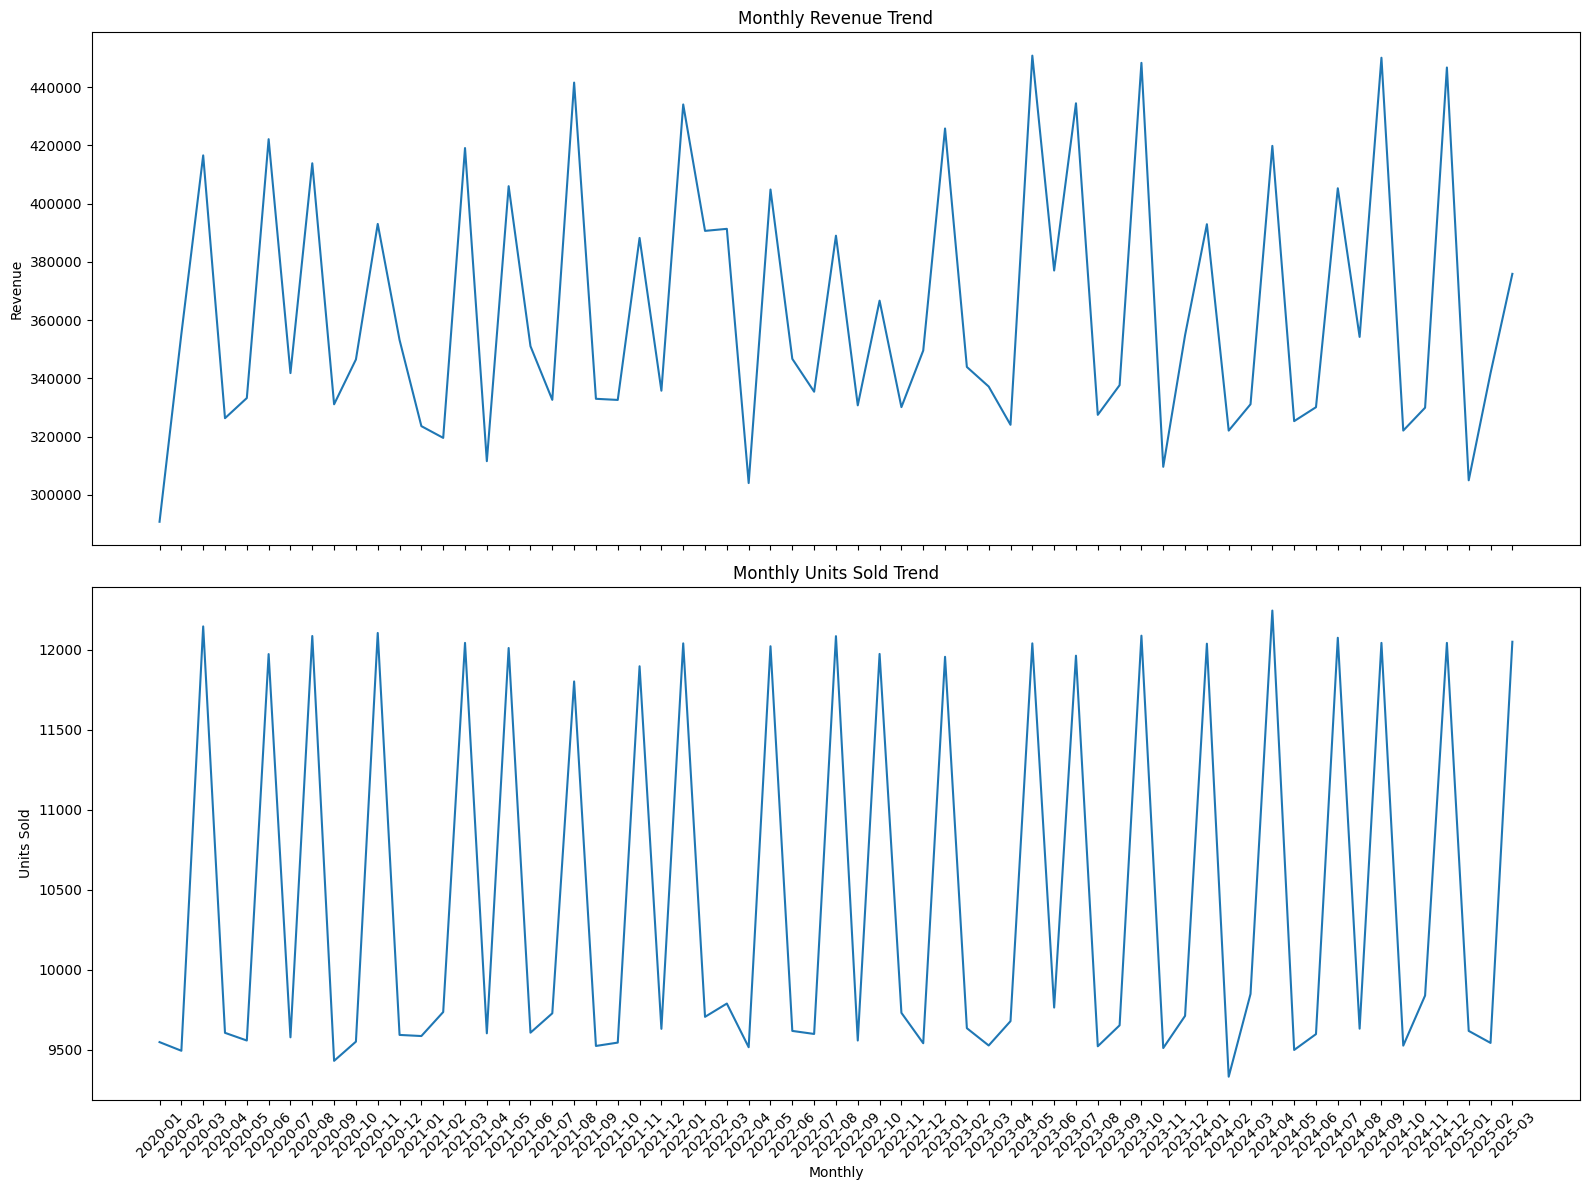

In [51]:
fig, axes = plt.subplots(2,1, sharex = True,figsize=(16,12))

sns.lineplot(data = Monthly , x = 'Monthly', y = 'Revenue', ax = axes[0])
axes[0].set_title('Monthly Revenue Trend')
axes[0].tick_params(axis='x',rotation=45)

sns.lineplot(data = Monthly , x = 'Monthly', y = 'Units Sold', ax = axes[1])
axes[1].set_title('Monthly Units Sold Trend')
axes[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

---
## 💰 Net Revenue Calculation
Net Revenue adjusts gross revenue by subtracting the estimated value of returned units (refunded at discounted price).


In [53]:
df['Net Revenue'] = df['Revenue'] - (df['Units Returned'] * df['Price'] * (1 - df['Discount']))
# Note: Assumes returned units are refunded at discounted price

In [54]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Monthly,Net Revenue
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986,2020-01,4511.0988
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000,2020-01,5908.8900
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000,2020-01,2078.5100
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000,2020-01,2249.8000
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108,2020-01,5488.9825


In [55]:
category_profit = df.groupby('Category')['Net Revenue'].sum().sort_values(ascending = False)

---
## 📊 Net Revenue by Category


In [57]:
category_profit

Category
Vitamin        4.260951e+06
Mineral        4.238539e+06
Performance    2.883582e+06
Protein        2.830554e+06
Amino Acid     1.451278e+06
Omega          1.438774e+06
Fat Burner     1.427997e+06
Hydration      1.398561e+06
Herbal         1.394053e+06
Sleep Aid      1.385159e+06
Name: Net Revenue, dtype: float64

**Insight:** The Net Revenue ranking mirrors the gross Revenue ranking, with Weight Loss leading.  
The difference between gross and net revenue per category reflects the financial impact of returns.  
Categories with higher return rates (Vitamins, Pre-Workout) show a slightly larger gap between gross and net — confirming returns are a real cost worth monitoring.


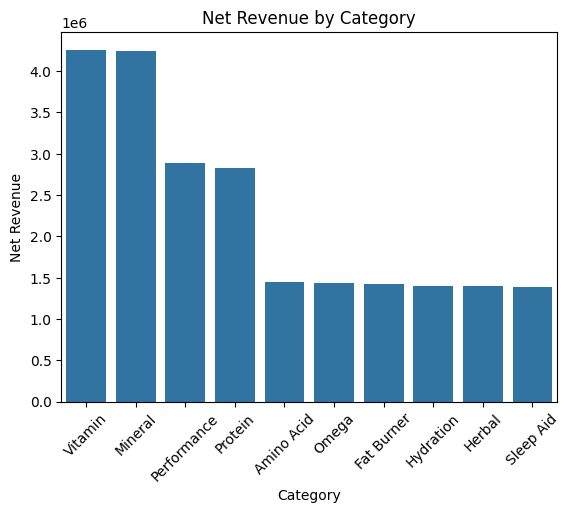

In [59]:
sns.barplot(x = category_profit.index, y = category_profit.values)
plt.title('Net Revenue by Category')
plt.ylabel('Net Revenue')
plt.xticks(rotation = 45)
plt.show()

---
## ✅ Conclusions & Key Takeaways

| Finding | Detail |
|---|---|
| **Top Category** | Weight Loss drives the most revenue (~26% of total) |
| **Top Products** | Fat Burner & Appetite Control lead product-level sales |
| **Platform** | Amazon is the #1 sales channel (~38–40% revenue share) |
| **Returns** | Vitamins & Pre-Workout have the highest return rates (~6%) |
| **Discounts** | Weak impact on revenue — volume is the real growth driver |
| **Growth** | Revenue grew ~11–12% over the analysis period |

### Business Recommendations
1. **Invest in Weight Loss and Vitamin categories** — they generate the most revenue
2. **Investigate Vitamin return drivers** — high return rate despite strong revenue suggests a quality/expectation gap
3. **Re-evaluate discount strategy** — discounts don't significantly boost revenue; margin protection should take priority
4. **Strengthen Amazon presence** — it's the dominant platform and deserves dedicated inventory and promotions planning
